# Quantifying Financial Risk from Penalty Exposure on Delayed Shipments

Objective: turn "some shipments get delayed and incur penalties" into a **dollar-quantified, per-shipment risk score** usable at route-planning time.

Approach - standard actuarial **frequency x severity** decomposition:

```
Expected Penalty Exposure = P(delay) x E[penalty_cost | delay]
```

- **Frequency** (`P(delay)`): reuse the trained Gradient Boosting delay classifier already in production (`app/model_artifacts.pkl`, built in `Final Code.ipynb`) rather than retraining it here.
- **Severity** (`E[penalty_cost | delay]`): a new regression model trained *only on shipments that were actually delayed* (`penalty_cost` is exactly 0 for every on-time shipment in this data - confirmed below - so severity is only meaningful conditional on delay).

Multiplying the two gives an expected-loss figure for **every** shipment, delayed or not, which is what route planning actually needs: "if I dispatch this shipment this way, what's my expected penalty exposure?"

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

df_main = pd.read_csv(r"C:\Users\thiru\Downloads\GFS_Project_Horizon.csv")
df_delay = pd.read_csv(r"C:\Users\thiru\Downloads\delay_labels.csv")
df = pd.merge(df_main, df_delay, on="shipment_id")
df['shipment_date'] = pd.to_datetime(df['shipment_date'], dayfirst=True, errors='coerce')
print("Merged shape:", df.shape)

Merged shape: (50500, 40)


In [2]:
# --- Confirm penalty_cost is a pure consequence of delay (justifies the frequency x severity split) ---
penalty_by_delay = df.groupby('delay_flag')['penalty_cost'].agg(
    count='count', mean='mean', median='median', total='sum',
    pct_nonzero=lambda s: (s > 0).mean(),
)
print(penalty_by_delay)
print("\nOverall delay rate:", df['delay_flag'].mean().round(4))
print("Total historical penalty cost (raw, pre-cleaning):", f"{df['penalty_cost'].sum():,.2f}")

            count         mean       median         total  pct_nonzero
delay_flag                                                            
0           42774     0.000000     0.000000  0.000000e+00          0.0
1            7726  5293.193894  5302.980725  4.089522e+07          1.0

Overall delay rate: 0.153
Total historical penalty cost (raw, pre-cleaning): 40,895,216.03


## Feature Engineering (reused from `Final Code.ipynb`)

Same pipeline as before, with one difference: `penalty_cost` is **kept** this time (it's the severity target), not dropped as leakage.

In [3]:
df_fe = df.copy()

# --- 1. Drop leakage columns (still leaky for OUR purposes: post-outcome, not the target) ---
leakage_cols = ['complaint_flag', 'customer_satisfaction_score']

# --- 1b. Drop raw high-cardinality identifier columns (no standalone signal) ---
id_cols = ['shipment_id', 'supplier_id', 'warehouse_id', 'route_id',
           'warehouse_manager_id', 'supplier_internal_code']

df_fe = df_fe.drop(columns=leakage_cols + id_cols)

print("Dropped columns:", leakage_cols + id_cols)
print("Remaining shape:", df_fe.shape)

Dropped columns: ['complaint_flag', 'customer_satisfaction_score', 'shipment_id', 'supplier_id', 'warehouse_id', 'route_id', 'warehouse_manager_id', 'supplier_internal_code']
Remaining shape: (50500, 32)


In [4]:
# --- 2. Clean messy categorical text (supplier_region has inconsistent casing/abbreviations) ---
df_fe['supplier_region'] = (
    df_fe['supplier_region']
    .str.strip()
    .str.upper()
    .replace({'N': 'NORTH'})
    .str.title()
)
print(df_fe['supplier_region'].value_counts())

supplier_region
North    14084
West     12347
South    12107
East     11962
Name: count, dtype: int64


In [5]:
# --- 3. Missing value handling ---
missing = df_fe.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:\n", missing)

for col in missing.index:
    if df_fe[col].dtype in ['float64', 'int64']:
        df_fe[f'{col}_was_missing'] = df_fe[col].isna().astype(int)
        df_fe[col] = df_fe[col].fillna(df_fe[col].median())
    else:
        df_fe[f'{col}_was_missing'] = df_fe[col].isna().astype(int)
        df_fe[col] = df_fe[col].fillna(df_fe[col].mode()[0])

print("\nRemaining missing values:", df_fe.isna().sum().sum())

Columns with missing values:
 vehicle_age_years    5158
rainfall_mm          5060
supplier_rating      5048
dtype: int64

Remaining missing values: 0


In [6]:
# --- 4. Date-derived features ---
df_fe['shipment_month'] = df_fe['shipment_date'].dt.month
df_fe['shipment_quarter'] = df_fe['shipment_date'].dt.quarter
df_fe['shipment_dayofweek'] = df_fe['shipment_date'].dt.dayofweek
df_fe['shipment_is_weekend'] = (df_fe['shipment_dayofweek'] >= 5).astype(int)

df_fe = df_fe.drop(columns=['shipment_date'])
df_fe[['shipment_month', 'shipment_quarter', 'shipment_dayofweek', 'shipment_is_weekend']].head()

,shipment_month,shipment_quarter,shipment_dayofweek,shipment_is_weekend
0,4,2,2,0
1,5,2,4,0
2,8,3,5,1
3,9,3,3,0
4,11,4,6,1


In [7]:
# --- 5. Domain-derived ratio & interaction features ---
eps = 1e-6

df_fe['shipment_density'] = df_fe['shipment_weight_kg'] / (df_fe['shipment_volume_cbm'] + eps)
df_fe['transport_cost_per_kg'] = df_fe['transportation_cost'] / (df_fe['shipment_weight_kg'] + eps)
df_fe['transport_cost_per_km'] = df_fe['transportation_cost'] / (df_fe['route_distance_km'] + eps)
df_fe['fuel_cost_per_km'] = df_fe['fuel_cost'] / (df_fe['route_distance_km'] + eps)
df_fe['avg_speed_kmph'] = df_fe['route_distance_km'] / (df_fe['estimated_travel_time_hrs'] + eps)
df_fe['total_lead_time_hrs'] = df_fe['warehouse_processing_time_hrs'] + df_fe['estimated_travel_time_hrs']
df_fe['maintenance_overdue_flag'] = (df_fe['maintenance_overdue_days'] > 0).astype(int)
df_fe['vehicle_risk_score'] = df_fe['vehicle_age_years'] + df_fe['maintenance_overdue_days']

rainfall_p75 = df_fe['rainfall_mm'].quantile(0.75)
df_fe['adverse_weather_flag'] = (
    (df_fe['storm_warning'] == 1) | (df_fe['rainfall_mm'] > rainfall_p75)
).astype(int)

df_fe['supplier_risk_index'] = df_fe['supplier_previous_delay_count'] / (df_fe['supplier_rating'] + 1)
df_fe['warehouse_units_in_use'] = df_fe['warehouse_capacity'] * (df_fe['warehouse_utilization_pct'] / 100)

new_feature_cols = ['shipment_density', 'transport_cost_per_kg', 'transport_cost_per_km',
                     'fuel_cost_per_km', 'avg_speed_kmph', 'total_lead_time_hrs',
                     'maintenance_overdue_flag', 'vehicle_risk_score', 'adverse_weather_flag',
                     'supplier_risk_index', 'warehouse_units_in_use']
df_fe[new_feature_cols].describe()

,shipment_density,transport_cost_per_kg,transport_cost_per_km,fuel_cost_per_km,avg_speed_kmph,total_lead_time_hrs,maintenance_overdue_flag,vehicle_risk_score,adverse_weather_flag,supplier_risk_index,warehouse_units_in_use
count,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000,50500.000000
mean,598.450037,4.293501,11.486938,3.505558,54.968242,40.514342,0.992792,12.448158,0.310535,0.037595,20603.349430
std,1446.421424,17.585713,2.020510,0.865662,8.664161,17.225253,0.084594,4.424918,0.462717,0.022229,10613.765706
min,0.556248,0.002770,8.000073,2.000001,40.000344,2.241663,0.000000,1.000000,0.000000,0.000000,1357.934521
25%,123.676662,0.705066,9.736570,2.760467,47.382666,26.472461,1.000000,9.000000,0.000000,0.022938,11741.548604
50%,248.670657,1.390085,11.496324,3.509137,55.000271,39.859361,1.000000,12.000000,0.000000,0.035719,19895.604902
75%,488.364912,2.784760,13.231208,4.255786,62.486206,53.310695,1.000000,16.000000,1.000000,0.050247,28380.885405
max,76436.604227,799.277708,14.999935,4.999959,69.999251,96.867109,1.000000,29.000000,1.000000,0.208406,49988.000000


In [8]:
# --- 6. Encode categoricals ---
priority_map = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
tier_map = {'Bronze': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3}

df_fe['shipment_priority'] = df_fe['shipment_priority'].map(priority_map)
df_fe['customer_tier'] = df_fe['customer_tier'].map(tier_map)

nominal_cols = ['shipment_type', 'supplier_region', 'vehicle_type', 'customer_region',
                'shipment_color_code', 'routing_template_version', 'operational_cluster_id']

df_encoded = pd.get_dummies(df_fe, columns=nominal_cols, drop_first=True)

print("Shape before encoding:", df_fe.shape)
print("Shape after encoding :", df_encoded.shape)

Shape before encoding: (50500, 49)
Shape after encoding : (50500, 84)


## Frequency Component: P(delay)

Reuse the trained Gradient Boosting classifier from `app/model_artifacts.pkl` (built in `Final Code.ipynb`) instead of retraining - it's already the production delay model, so the risk score built here stays consistent with what the app shows.

In [9]:
delay_artifacts = joblib.load(r"C:\Users\thiru\Downloads\app\model_artifacts.pkl")
delay_model = delay_artifacts['model']
delay_selected_features = delay_artifacts['selected_features']
delay_all_columns = delay_artifacts['all_columns']

X_delay_full = df_encoded.drop(columns=['delay_flag'], errors='ignore')
X_delay_full = X_delay_full.apply(lambda c: c.astype(int) if c.dtype == bool else c)
X_delay_full = X_delay_full.reindex(columns=delay_all_columns, fill_value=0)[delay_selected_features]

p_delay_raw = delay_model.predict_proba(X_delay_full)[:, 1]
df_fe['p_delay_raw'] = p_delay_raw
# Hard classification decision - identical to the DELAYED/ON TIME label already shown in the
# app's Predict tab (threshold 0.5 on the raw, uncalibrated probability). Used below as the
# deterministic gate for the two-stage/hurdle model.
df_fe['pred_delay_hard'] = (p_delay_raw >= 0.5).astype(int)

# --- Step 1: prior correction ---
# The classifier was trained on SMOTE-balanced data (50/50 delayed/on-time), so its raw
# predict_proba output reflects a 50% base rate, not the true ~15% delay rate in this
# population. Standard prior correction (Elkan, 2001) rescales probabilities from the
# training prior (beta) back to the true population prior (pi):
#
#   p_corrected = (p * pi/beta) / (p * pi/beta + (1-p) * (1-pi)/(1-beta))
beta = 0.5  # SMOTE-balanced training prior
pi = df_fe['delay_flag'].mean()  # true population delay rate

odds = p_delay_raw * (pi / beta)
odds_complement = (1 - p_delay_raw) * ((1 - pi) / (1 - beta))
p_delay_corrected = odds / (odds + odds_complement)

# --- Step 2: mean-matching anchor ---
# SMOTE also distorts the feature distribution (not just the class prior), so step 1 alone
# doesn't land the average exactly on pi (empirically ends up around 0.12 instead of 0.153).
# Rescale multiplicatively so the *average* predicted probability exactly equals the true
# delay rate - this keeps each shipment's relative ranking (who's riskier than whom) intact
# while removing the frequency model's aggregate bias, so any remaining gap between expected
# and actual total exposure can be attributed to the severity model instead of a miscalibrated
# frequency estimate.
p_delay = np.clip(p_delay_corrected * (pi / p_delay_corrected.mean()), 0, 1)

df_fe['p_delay'] = p_delay
df_encoded['p_delay'] = p_delay

print("Actual delay rate                 :", round(pi, 4))
print("Mean RAW predicted P(delay)       :", round(p_delay_raw.mean(), 4), " <- biased by SMOTE training")
print("Mean prior-corrected P(delay)     :", round(p_delay_corrected.mean(), 4), " <- closer, not exact")
print("Mean FINAL (mean-matched) P(delay):", round(p_delay.mean(), 4), " <- matches actual delay rate by construction")
print()
print("Hard classification (>=0.5 on raw proba) - predicted delayed:", df_fe['pred_delay_hard'].sum(),
      f"({df_fe['pred_delay_hard'].mean():.1%})")
print("Actual delayed                                              :", df_fe['delay_flag'].sum(),
      f"({df_fe['delay_flag'].mean():.1%})")

Actual delay rate                 : 0.153
Mean RAW predicted P(delay)       : 0.298  <- biased by SMOTE training
Mean prior-corrected P(delay)     : 0.1165  <- closer, not exact
Mean FINAL (mean-matched) P(delay): 0.1518  <- matches actual delay rate by construction

Hard classification (>=0.5 on raw proba) - predicted delayed: 11550 (22.9%)
Actual delayed                                              : 7726 (15.3%)


## Severity Component: E[penalty_cost | delay]

Trained **only on shipments that were actually delayed** (`penalty_cost` is always 0 otherwise, confirmed earlier). Same leakage exclusions as `Cost_Forecasting.ipynb` - `transportation_cost`, `fuel_cost`, `warehouse_cost` and their ratios are outcomes settled alongside the penalty, not known before dispatch - plus `delay_flag` (constant on this subset) and `p_delay` (belongs to the frequency stage, not severity).

In [10]:
severity_leakage_cols = ['transportation_cost', 'transport_cost_per_kg', 'transport_cost_per_km',
                          'fuel_cost', 'fuel_cost_per_km', 'warehouse_cost', 'delay_flag', 'p_delay']

y_sev_full = df_encoded['penalty_cost']
X_sev_full = df_encoded.drop(columns=['penalty_cost'] + severity_leakage_cols)
X_sev_full = X_sev_full.apply(lambda c: c.astype(int) if c.dtype == bool else c)

delayed_mask = df_encoded['delay_flag'] == 1
X_sev = X_sev_full[delayed_mask]
y_sev = y_sev_full[delayed_mask]

print("Full dataset:", X_sev_full.shape)
print("Delayed-only subset used for severity training:", X_sev.shape)
print("penalty_cost summary on delayed subset:\n", y_sev.describe())

Full dataset: (50500, 76)
Delayed-only subset used for severity training: (7726, 76)
penalty_cost summary on delayed subset:
 count    7726.000000
mean     5293.193894
std      2734.824728
min       500.992393
25%      2968.223618
50%      5302.980725
75%      7688.070911
max      9998.160093
Name: penalty_cost, dtype: float64


## Feature Selection (Regression, delayed-shipments-only)

In [11]:
corr_with_target = X_sev.corrwith(y_sev).sort_values(key=lambda s: s.abs(), ascending=False)
corr_with_target.head(20)

operational_cluster_id_18       -0.026680
operational_cluster_id_17       -0.023414
operational_cluster_id_9         0.022337
operational_cluster_id_7        -0.022320
adverse_weather_flag             0.021796
supplier_region_North            0.021050
shipment_weight_kg               0.020076
maintenance_overdue_days        -0.019699
rainfall_mm_was_missing         -0.018994
inventory_available             -0.018654
storm_warning                    0.017806
route_risk_score                 0.017632
supplier_rating_was_missing      0.015937
customer_tier                    0.014587
operational_cluster_id_11        0.014388
warehouse_processing_time_hrs    0.014130
warehouse_units_in_use          -0.013569
vehicle_age_years                0.012782
total_lead_time_hrs              0.011369
supplier_region_West            -0.011176
dtype: float64

In [12]:
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X_sev, y_sev, discrete_features='auto', random_state=42)
mi_series = pd.Series(mi_scores, index=X_sev.columns).sort_values(ascending=False)
mi_series.head(20)

shipment_dayofweek               0.021615
avg_speed_kmph                   0.020093
shipment_month                   0.018856
maintenance_overdue_days         0.018544
warehouse_processing_time_hrs    0.017810
warehouse_capacity               0.016809
shipment_priority                0.015261
supplier_rating                  0.013418
shipment_weight_kg               0.011886
supplier_risk_index              0.011321
shipment_quarter                 0.010791
shipment_color_code_Green        0.010128
inventory_available              0.009693
vehicle_risk_score               0.009596
shipment_color_code_Blue         0.008275
total_lead_time_hrs              0.008095
customer_region_West             0.007772
shipment_is_weekend              0.006667
routing_template_version_3       0.006410
warehouse_units_in_use           0.006278
dtype: float64

In [13]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_sev, y_sev)
rf_importance = pd.Series(rf.feature_importances_, index=X_sev.columns).sort_values(ascending=False)
rf_importance.head(20)

warehouse_processing_time_hrs    0.048936
inventory_available              0.048787
temperature                      0.048713
supplier_rating                  0.046597
avg_speed_kmph                   0.046039
rainfall_mm                      0.045354
shipment_weight_kg               0.044076
shipment_volume_cbm              0.043540
supplier_risk_index              0.042722
warehouse_utilization_pct        0.042122
route_risk_score                 0.041403
shipment_density                 0.038981
warehouse_capacity               0.038835
warehouse_units_in_use           0.036606
total_lead_time_hrs              0.033913
route_distance_km                0.033072
estimated_travel_time_hrs        0.030149
vehicle_risk_score               0.023704
vehicle_age_years                0.021531
shipment_month                   0.021447
dtype: float64

In [14]:
summary = pd.DataFrame({
    'abs_corr': corr_with_target.abs(),
    'mutual_info': mi_series,
    'rf_importance': rf_importance,
})
summary['rank_corr'] = summary['abs_corr'].rank(ascending=False)
summary['rank_mi'] = summary['mutual_info'].rank(ascending=False)
summary['rank_rf'] = summary['rf_importance'].rank(ascending=False)
summary['avg_rank'] = summary[['rank_corr', 'rank_mi', 'rank_rf']].mean(axis=1)

feature_ranking = summary.sort_values('avg_rank')

TOP_N = 15
selected_features_severity = feature_ranking.head(TOP_N).index.tolist()
print(f"Top {TOP_N} features selected for severity modelling:")
for f in selected_features_severity:
    print(" -", f)

Top 15 features selected for severity modelling:
 - warehouse_processing_time_hrs
 - shipment_weight_kg
 - inventory_available
 - maintenance_overdue_days
 - avg_speed_kmph
 - warehouse_capacity
 - total_lead_time_hrs
 - warehouse_units_in_use
 - supplier_rating
 - temperature
 - shipment_month
 - rainfall_mm
 - customer_tier
 - supplier_region_West
 - customer_region_West


## Train/Test Split & Model Building

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

X_sev_sel = X_sev[selected_features_severity]
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sev_sel, y_sev, test_size=0.2, random_state=42
)
print("Train shape:", X_train_s.shape, "| Test shape:", X_test_s.shape)

Train shape: (6180, 15) | Test shape: (1546, 15)


In [16]:
def evaluate_regressor(name, m, X_te, y_te):
    preds = np.clip(m.predict(X_te), 0, None)  # penalty cost can't be negative
    return {
        'model': name,
        'MAE': mean_absolute_error(y_te, preds),
        'RMSE': mean_squared_error(y_te, preds) ** 0.5,
        'MAPE': mean_absolute_percentage_error(y_te, preds),
        'R2': r2_score(y_te, preds),
    }, preds

results = []

lin_reg_sev = LinearRegression()
lin_reg_sev.fit(X_train_s, y_train_s)
res, _ = evaluate_regressor('Linear Regression', lin_reg_sev, X_test_s, y_test_s)
results.append(res)

hgb_sev_model = HistGradientBoostingRegressor(random_state=42)
hgb_sev_model.fit(X_train_s, y_train_s)
res, _ = evaluate_regressor('Gradient Boosting', hgb_sev_model, X_test_s, y_test_s)
results.append(res)

results_df_sev = pd.DataFrame(results).set_index('model')
results_df_sev

,MAE,RMSE,MAPE,R2
model,,,,
Linear Regression,2447.353471,2802.778217,0.948158,-0.004068
Gradient Boosting,2466.294080,2852.708939,0.952612,-0.040161


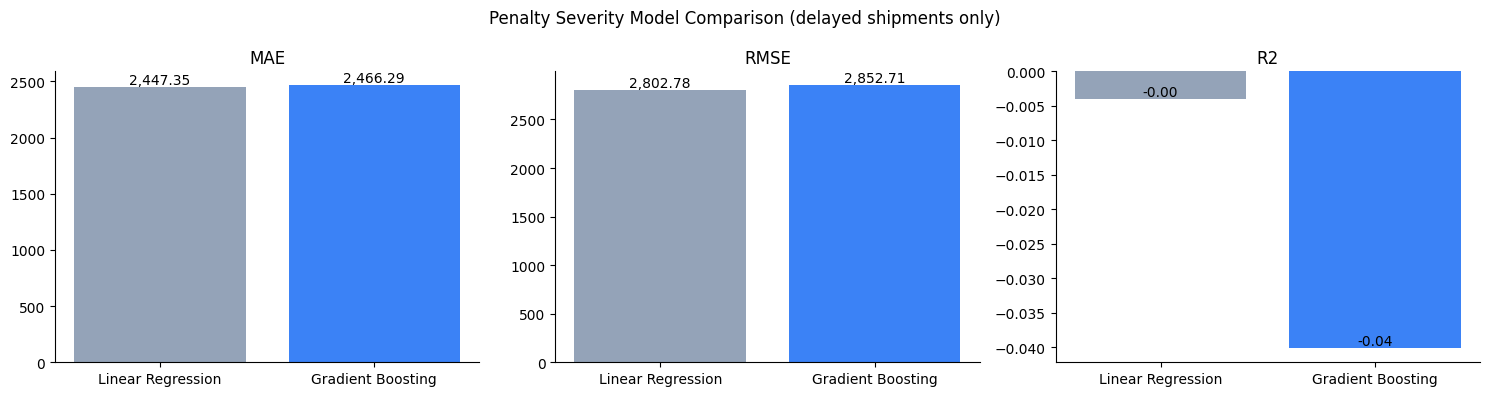

Best severity model by MAE: Linear Regression


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#94A3B8', '#3B82F6']
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    ax.bar(results_df_sev.index, results_df_sev[metric], color=colors)
    ax.set_title(metric)
    ax.spines[['top', 'right']].set_visible(False)
    for i, v in enumerate(results_df_sev[metric]):
        ax.text(i, v, f'{v:,.2f}', ha='center', va='bottom')
fig.suptitle('Penalty Severity Model Comparison (delayed shipments only)')
plt.tight_layout()
plt.show()

best_sev_name = results_df_sev['MAE'].idxmin()
best_sev_model = {'Linear Regression': lin_reg_sev, 'Gradient Boosting': hgb_sev_model}[best_sev_name]
print("Best severity model by MAE:", best_sev_name)

## Expected Penalty Exposure (Frequency x Severity, all shipments)

Apply the severity model to **every** shipment (not just delayed ones) to get "what the penalty would be *if* this shipment were delayed", then multiply by that shipment's actual `P(delay)` from the frequency model. This is the per-shipment expected financial risk a planner can act on before dispatch.

In [18]:
X_sev_all_sel = X_sev_full[selected_features_severity]
predicted_severity_all = np.clip(best_sev_model.predict(X_sev_all_sel), 0, None)

df_fe['predicted_severity'] = predicted_severity_all
df_fe['expected_penalty_exposure'] = df_fe['p_delay'] * df_fe['predicted_severity']

df_fe[['delay_flag', 'penalty_cost', 'p_delay', 'predicted_severity', 'expected_penalty_exposure']].head(10)

,delay_flag,penalty_cost,p_delay,predicted_severity,expected_penalty_exposure
0,0,0.0,0.070210,5225.901877,366.908481
1,0,0.0,0.032748,5344.786024,175.032805
2,0,0.0,0.054687,5401.200366,295.375846
3,0,0.0,0.006696,5357.257190,35.871613
4,0,0.0,0.033669,5045.964929,169.893771
5,0,0.0,0.006527,5245.927246,34.240832
6,0,0.0,0.011689,5011.826326,58.585160
7,0,0.0,0.005901,5202.593036,30.700330
8,0,0.0,0.156910,5326.587877,835.792732
9,0,0.0,0.037489,5136.857861,192.576541


In [19]:
# --- Portfolio-level calibration check: aggregate expected exposure vs. actual realized penalty cost ---
total_expected = df_fe['expected_penalty_exposure'].sum()
total_actual = df_fe['penalty_cost'].sum()

print(f"Total EXPECTED penalty exposure (model, all {len(df_fe):,} shipments) : {total_expected:,.2f}")
print(f"Total ACTUAL realized penalty cost (historical)                     : {total_actual:,.2f}")
print(f"Difference                                                          : {(total_expected - total_actual):,.2f} "
      f"({(total_expected - total_actual) / total_actual:+.1%})")
print()
print(f"Average expected exposure per shipment : {df_fe['expected_penalty_exposure'].mean():,.2f}")
print(f"Median expected exposure per shipment  : {df_fe['expected_penalty_exposure'].median():,.2f}")

Total EXPECTED penalty exposure (model, all 50,500 shipments) : 40,388,502.11
Total ACTUAL realized penalty cost (historical)                     : 40,895,216.03
Difference                                                          : -506,713.92 (-1.2%)

Average expected exposure per shipment : 799.77
Median expected exposure per shipment  : 288.19


In [20]:
# --- Where is the financial risk concentrated? ---
for col in ['supplier_region', 'vehicle_type', 'customer_tier']:
    seg = df_fe.groupby(col)['expected_penalty_exposure'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)
    seg.columns = ['total_expected_exposure', 'avg_expected_exposure', 'n_shipments']
    print(f"--- By {col} ---")
    print(seg.round(2))
    print()

--- By supplier_region ---
                 total_expected_exposure  avg_expected_exposure  n_shipments
supplier_region                                                             
North                        11317373.73                 803.56        14084
South                         9821942.86                 811.26        12107
West                          9675269.74                 783.61        12347
East                          9573915.78                 800.36        11962

--- By vehicle_type ---
              total_expected_exposure  avg_expected_exposure  n_shipments
vehicle_type                                                             
Truck                     10193054.92                 802.67        12699
Mini Truck                10146245.66                 794.23        12775
Trailer                   10025845.47                 791.74        12663
Container                 10023356.07                 810.75        12363

--- By customer_tier ---
               t

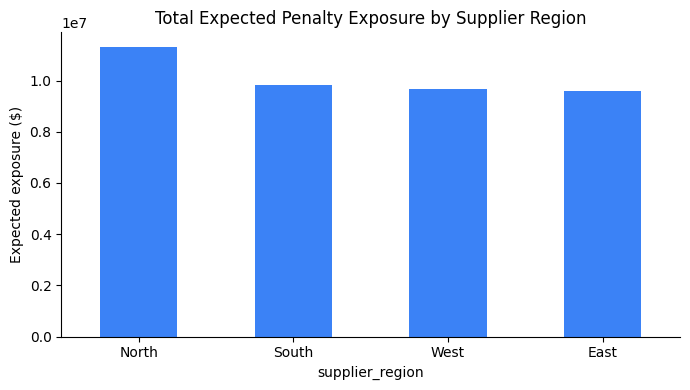

In [21]:
supplier_region_exposure = df_fe.groupby('supplier_region')['expected_penalty_exposure'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
supplier_region_exposure.plot.bar(ax=ax, color='#3B82F6')
ax.set_title('Total Expected Penalty Exposure by Supplier Region')
ax.set_ylabel('Expected exposure ($)')
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
# --- Flag the highest-risk shipments for proactive mitigation before dispatch ---
exposure_review_threshold = df_fe['expected_penalty_exposure'].quantile(0.90)
high_risk = df_fe['expected_penalty_exposure'] > exposure_review_threshold

print(f"Review threshold (90th percentile of expected exposure): {exposure_review_threshold:,.2f}")
print(f"Shipments flagged as high financial risk: {high_risk.sum():,} / {len(df_fe):,} ({high_risk.mean():.1%})")
print(f"Those flagged shipments account for {df_fe.loc[high_risk, 'expected_penalty_exposure'].sum():,.0f} "
      f"of the {total_expected:,.0f} total expected exposure "
      f"({df_fe.loc[high_risk, 'expected_penalty_exposure'].sum() / total_expected:.1%})")

df_fe.loc[high_risk, ['p_delay', 'predicted_severity', 'expected_penalty_exposure',
                       'supplier_region', 'vehicle_type', 'route_risk_score']].sort_values(
    'expected_penalty_exposure', ascending=False
).head(10)

Review threshold (90th percentile of expected exposure): 2,409.46
Shipments flagged as high financial risk: 5,050 / 50,500 (10.0%)
Those flagged shipments account for 18,977,023 of the 40,388,502 total expected exposure (47.0%)


,p_delay,predicted_severity,expected_penalty_exposure,supplier_region,vehicle_type,route_risk_score
14563,1.000000,5602.589022,5602.589022,North,Mini Truck,86
6115,0.864901,6466.968474,5593.289262,East,Container,16
10735,1.000000,5581.642359,5581.642359,North,Mini Truck,79
28153,1.000000,5562.324521,5562.324521,South,Truck,87
38273,1.000000,5559.262806,5559.262806,South,Container,90
20514,1.000000,5556.996316,5556.996316,South,Container,77
47878,1.000000,5547.143702,5547.143702,West,Truck,84
6021,1.000000,5542.760743,5542.760743,East,Truck,76
46438,0.989258,5602.720632,5542.535900,South,Truck,49
32076,1.000000,5536.755198,5536.755198,East,Trailer,14


## Two-Stage Model (Deterministic Split + Regression) - Hurdle Alternative

`expected_penalty_exposure` above is a *smooth* risk score - `P(delay) x E[penalty|delay]` - which is nonzero for essentially every shipment, since a continuous probability is almost never exactly 0. That's the right tool for portfolio-level ranking, but confusing at the single-shipment level: a shipment classified ON TIME still shows a nonzero dollar figure.

`penalty_cost` is a classic **zero-inflated** target (always exactly $0 unless delayed - confirmed at the top of this notebook), which is exactly what a **two-part / hurdle model** is designed for. It replaces the continuous weighting with a **deterministic gate**:

```
predicted_penalty_cost = severity_model.predict(features)   if the hard classifier says DELAYED
                        = 0                                  if the hard classifier says ON TIME
```

- **Stage 1 (deterministic split):** reuses the exact same DELAYED/ON TIME decision already shown in the app (`raw P(delay) >= 0.5`).
- **Stage 2 (regression):** reuses the severity model already trained above - no new model needed, only a different way of combining the two existing pieces.

Trade-off versus the smooth version: this gives a clean, actionable point estimate (either "$0 expected" or a concrete dollar figure) and directly resolves the "why is there a penalty when it's predicted ON TIME" confusion - **but it comes at a real accuracy cost, not just a stylistic one.** As shown below, the hard 0.5 threshold inherits the same SMOTE-driven bias that affected the raw probability *values* (more shipments cross the threshold than should), so this method's portfolio-level total ends up considerably less accurate than the soft score's. Use it for single-shipment display; keep using the soft score wherever an aggregate/portfolio total matters.

In [23]:
df_fe['predicted_penalty_two_stage'] = np.where(
    df_fe['pred_delay_hard'] == 1, df_fe['predicted_severity'], 0.0
)

n_predicted_delayed = df_fe['pred_delay_hard'].sum()
n_actual_delayed = df_fe['delay_flag'].sum()
print(f"Shipments where Stage 1 gates open (predicted DELAYED): {n_predicted_delayed:,} "
      f"({df_fe['pred_delay_hard'].mean():.1%})")
print(f"Shipments actually delayed                             : {n_actual_delayed:,} "
      f"({df_fe['delay_flag'].mean():.1%})")

df_fe[['delay_flag', 'penalty_cost', 'pred_delay_hard', 'predicted_severity',
       'predicted_penalty_two_stage', 'expected_penalty_exposure']].head(10)

Shipments where Stage 1 gates open (predicted DELAYED): 11,550 (22.9%)
Shipments actually delayed                             : 7,726 (15.3%)


,delay_flag,penalty_cost,pred_delay_hard,predicted_severity,predicted_penalty_two_stage,expected_penalty_exposure
0,0,0.0,0,5225.901877,0.0,366.908481
1,0,0.0,0,5344.786024,0.0,175.032805
2,0,0.0,0,5401.200366,0.0,295.375846
3,0,0.0,0,5357.257190,0.0,35.871613
4,0,0.0,0,5045.964929,0.0,169.893771
5,0,0.0,0,5245.927246,0.0,34.240832
6,0,0.0,0,5011.826326,0.0,58.585160
7,0,0.0,0,5202.593036,0.0,30.700330
8,0,0.0,0,5326.587877,0.0,835.792732
9,0,0.0,0,5136.857861,0.0,192.576541


In [24]:
# --- Compare the two combination methods against actual penalty_cost, per shipment, across ALL 50,500 rows ---
actual = df_fe['penalty_cost']
hard_pred = df_fe['predicted_penalty_two_stage']
soft_pred = df_fe['expected_penalty_exposure']

comparison = pd.DataFrame({
    'method': ['Two-Stage (hurdle, hard split)', 'Frequency x Severity (soft, continuous)'],
    'total_predicted': [hard_pred.sum(), soft_pred.sum()],
    'total_actual': [actual.sum(), actual.sum()],
    'MAE_vs_actual': [
        mean_absolute_error(actual, hard_pred),
        mean_absolute_error(actual, soft_pred),
    ],
    'pct_shipments_nonzero': [(hard_pred > 0).mean(), (soft_pred > 0).mean()],
}).set_index('method')
comparison['total_diff_pct'] = (comparison['total_predicted'] - comparison['total_actual']) / comparison['total_actual']
comparison

,total_predicted,total_actual,MAE_vs_actual,pct_shipments_nonzero,total_diff_pct
method,,,,,
"Two-Stage (hurdle, hard split)",6.085186e+07,4.089522e+07,1142.902300,0.228713,0.487995
"Frequency x Severity (soft, continuous)",4.038850e+07,4.089522e+07,995.317588,1.000000,-0.012391


In [25]:
# --- Review threshold for the two-stage method's own distribution ---
# (Computed only among shipments where the gate is open - among ON TIME shipments it's always
# 0 by construction, so a percentile over the full population would just measure what fraction
# of shipments are predicted delayed, not financial severity among the delayed ones.)
two_stage_gated = df_fe.loc[df_fe['pred_delay_hard'] == 1, 'predicted_penalty_two_stage']
two_stage_review_threshold = two_stage_gated.quantile(0.90)
high_risk_two_stage = df_fe['predicted_penalty_two_stage'] > two_stage_review_threshold

print(f"Two-stage review threshold (90th percentile, among predicted-DELAYED shipments): "
      f"{two_stage_review_threshold:,.2f}")
print(f"Shipments flagged as high financial risk: {high_risk_two_stage.sum():,} / {len(df_fe):,} "
      f"({high_risk_two_stage.mean():.1%})")

Two-stage review threshold (90th percentile, among predicted-DELAYED shipments): 5,440.99
Shipments flagged as high financial risk: 1,155 / 50,500 (2.3%)


### Notes

- **Two combination methods, two different jobs - and a real accuracy trade-off between them.** Measured against actual `penalty_cost` across all 50,500 shipments: the **soft** frequency x severity score totals $40.39M (-1.2% vs actual $40.90M, MAE $995/shipment); the **hard two-stage** model totals $60.85M (**+48.8%** overstated, MAE $1,143/shipment). The hard model is *not* better calibrated - it's simpler to read (a $0 or a concrete number instead of always-nonzero) at a real cost in aggregate accuracy. Use it for the single-shipment app display; keep using the soft score for portfolio-level totals and the segment breakdowns above.
- **Why the hard model overstates: the SMOTE bias affects the classification count too, not just the probability value.** The reused delay classifier flags 22.9% of shipments as DELAYED (`raw P(delay) >= 0.5`) vs. an actual delay rate of 15.3% - the same upward bias from SMOTE-balanced training that inflated the probability *values* also pushes more shipments over the 0.5 threshold than should cross it. Prior correction fixes the probability value (used in the soft score) but doesn't change which shipments cross a fixed 0.5 threshold, so the hard gate inherits the bias directly.
- The portfolio-level calibration checks (expected vs. actual total penalty cost, for both methods) are the thing to watch after any retrain - if either drifts further from parity, suspect a similar prior mismatch before trusting the dollar figures.
- A small number of high-severity delayed shipments dominate `penalty_cost` in this data (std $\approx$ mean on the delayed subset), so the severity model's MAE/RMSE will look large in absolute terms even if directionally useful - judge it as a ranking tool (which routes/suppliers are relatively riskier) more than a precise dollar forecaster.
- Segment breakdowns (supplier region, vehicle type, customer tier) point at *where* to focus mitigation (e.g. maintenance schedules, supplier SLAs, route changes) rather than only flagging individual shipments.
- Re-run this notebook whenever the underlying delay model (`app/model_artifacts.pkl`) is retrained, since both the frequency component and the two-stage gate depend on it directly.

## Export Model & Artifacts for the App

Saves what the Streamlit app needs to show `expected_penalty_exposure` alongside delay risk and cost forecast for a single entered shipment: the severity model, its training-time column layout, and the calibration constants (`beta`, `pi`, `mean_match_scale`) so the app can reproduce the exact same prior-correction + mean-matching pipeline used here on a single new prediction (a single row has no population mean of its own to match, so the scale factor learned here must be reused as-is).

In [26]:
mean_match_scale = pi / p_delay_corrected.mean()

penalty_risk_artifacts = {
    'severity_model': best_sev_model,
    'severity_model_name': best_sev_name,
    'severity_selected_features': selected_features_severity,
    'severity_all_columns': X_sev_full.columns.tolist(),
    'severity_leakage_cols': severity_leakage_cols,
    'beta': beta,
    'pi': float(pi),
    'mean_match_scale': float(mean_match_scale),
    'exposure_review_threshold': float(exposure_review_threshold),
    'two_stage_review_threshold': float(two_stage_review_threshold),
    'hard_threshold': 0.5,
    'test_metrics': results_df_sev.loc[best_sev_name].to_dict(),
}

joblib.dump(penalty_risk_artifacts, 'app/penalty_risk_artifacts.pkl')
print('Saved app/penalty_risk_artifacts.pkl')
print('Best severity model:', best_sev_name)
print('Calibration: beta =', beta, '| pi =', round(pi, 4), '| mean_match_scale =', round(mean_match_scale, 4))
print('Soft exposure review threshold:', round(exposure_review_threshold, 2))
print('Two-stage review threshold:', round(two_stage_review_threshold, 2))

Saved app/penalty_risk_artifacts.pkl
Best severity model: Linear Regression
Calibration: beta = 0.5 | pi = 0.153 | mean_match_scale = 1.3134
Soft exposure review threshold: 2409.46
Two-stage review threshold: 5440.99
